In [2]:
from ast import literal_eval
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Load dataset
dataset = pd.read_csv('train.csv')

# Flatten JSON
records = []
for _, row in dataset.iterrows():
    problems = literal_eval(row['problems'])
    record = {
        'id': row['id'],
        'paragraph': row['paragraph'],
        'question': problems['question'],
        'choices': problems['choices'],
        'answer': problems.get('answer', None),
        'question_plus': problems.get('question_plus', None),
    }
    records.append(record)

df = pd.DataFrame(records)

In [7]:
df = pd.DataFrame(records)

df.info()
print("📊 기본 데이터 정보")
print("="*80)
print(f"전체 샘플 수: {len(df)}")
print(f"컬럼: {list(df.columns)}")
print(f"\n결측치:\n{df.isnull().sum()}")
print(f"\n데이터 타입:\n{df.dtypes}")

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031 entries, 0 to 2030
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             2031 non-null   object
 1   paragraph      2031 non-null   object
 2   question       2031 non-null   object
 3   choices        2031 non-null   object
 4   answer         2031 non-null   int64 
 5   question_plus  0 non-null      object
dtypes: int64(1), object(5)
memory usage: 95.3+ KB
📊 기본 데이터 정보
전체 샘플 수: 2031
컬럼: ['id', 'paragraph', 'question', 'choices', 'answer', 'question_plus']

결측치:
id                  0
paragraph           0
question            0
choices             0
answer              0
question_plus    2031
dtype: int64

데이터 타입:
id               object
paragraph        object
question         object
choices          object
answer            int64
question_plus    object
dtype: object


,id,paragraph,question,choices,answer,question_plus
0,generation-for-nlp-425,"상소하여 아뢰기를 , “신이 좌참 찬 송준길이 올린 차자를 보았는데 , 상복(喪服)...",상소한 인물이 속한 붕당에 대한 설명으로 옳은 것만을 모두 고르면?,"[ㄱ, ㄴ, ㄱ, ㄷ, ㄴ, ㄹ, ㄷ, ㄹ]",2,None
1,generation-for-nlp-426,"(가)은/는 의병계열과 애국계몽 운동 계열의 비밀결사가 모여 결성된 조직으로, 총사...",(가)에 대한 설명으로 옳지 않은 것은?,"[고려 문종 때에 남경(南京)으로 승격되었다., 종루(鐘樓), 이현, 칠패 등에서 ...",1,None
2,generation-for-nlp-427,나는 삼한(三韓) 산천의 음덕을 입어 대업을 이루었다.(가)는/은 수덕(水德)이 순...,(가) 지역에 대한 설명으로 옳은 것은?,"[이곳에 대장도감을 설치하여 재조대장경을 만들었다., 지눌이 이곳에서 수선사 결사운...",4,None
3,generation-for-nlp-428,이 날 소정방이 부총관 김인문 등과 함께 기 벌포에 도착하여 백제 군사와 마주쳤다....,밑줄 친 ‘그’에 대한 설명으로 옳은 것은?,"[살수에서 수의 군대를 물리쳤다 ., 김춘추 의 신라 왕위 계승을 지원하였다 ., ...",2,None
4,generation-for-nlp-429,"선비들 수만 명이 대궐 앞에 모여 만 동묘와 서원을 다시 설립할 것을 청하니, (가...",(가) 인물이 추진한 정책으로 옳지 않은 것은?,"[사창제를 실시하였다 ., 대전회통을 편찬하였다 ., 비변사의 기능을 강화하였다 ....",3,None


answer
1    948
2    450
3    319
4    283
5     31
Name: count, dtype: int64
answer
1    46.676514
2    22.156573
3    15.706548
4    13.934023
5     1.526342
Name: proportion, dtype: float64


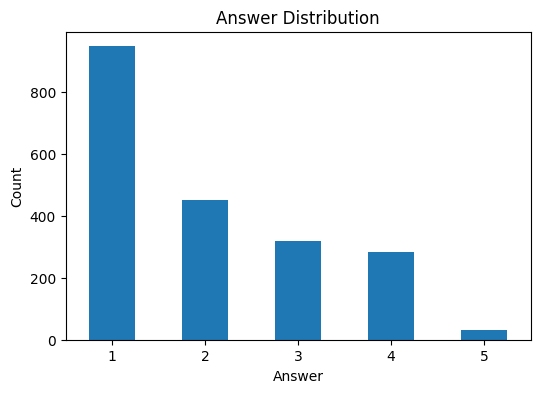

In [9]:
import matplotlib.pyplot as plt
import numpy as np

answer_counts = df['answer'].value_counts(dropna=True)
answer_ratios = df['answer'].value_counts(normalize=True, dropna=True) * 100

print(answer_counts)
print(answer_ratios)

plt.figure(figsize=(6,4))
answer_counts.plot(kind='bar')
plt.title("Answer Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()



[Question 통계]
평균: 39.24
중앙값: 37.00
최소: 10
최대: 152
표준편차: 12.98


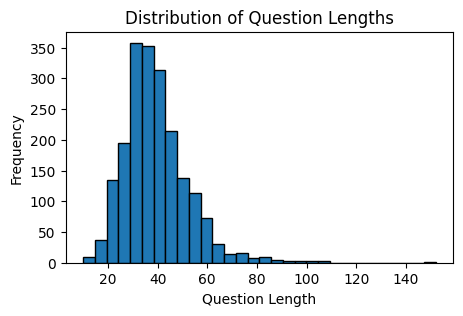

In [5]:
df['question_plus'] = df['question_plus'].fillna('')
df['full_question'] = df.apply(
    lambda x: x['question'] + ' ' + x['question_plus'] if x['question_plus'] else x['question'],
    axis=1
)

df['question_length'] = df['full_question'].apply(len)

print("\n[Question 통계]")
print(f"평균: {df['question_length'].mean():.2f}")
print(f"중앙값: {df['question_length'].median():.2f}")
print(f"최소: {df['question_length'].min()}")
print(f"최대: {df['question_length'].max()}")
print(f"표준편차: {df['question_length'].std():.2f}")

plt.figure(figsize=(5,3))
plt.hist(df['question_length'], bins=30, edgecolor='black')
plt.title('Distribution of Question Lengths')
plt.xlabel('Question Length')
plt.ylabel('Frequency')
plt.show()



[Paragraph 통계]
평균: 735.32
중앙값: 699.00
최소: 15
최대: 2017
표준편차: 462.60


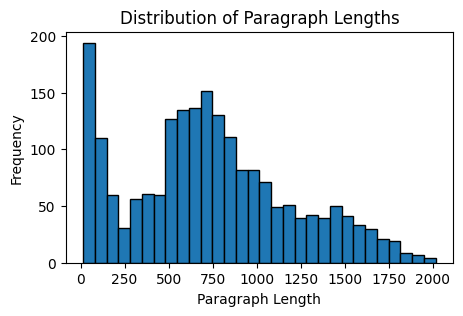

In [12]:
df['paragraph_length'] = df['paragraph'].apply(len)

print("\n[Paragraph 통계]")
print(f"평균: {df['paragraph_length'].mean():.2f}")
print(f"중앙값: {df['paragraph_length'].median():.2f}")
print(f"최소: {df['paragraph_length'].min()}")
print(f"최대: {df['paragraph_length'].max()}")
print(f"표준편차: {df['paragraph_length'].std():.2f}")

plt.figure(figsize=(5,3))
plt.hist(df['paragraph_length'], bins=30, edgecolor='black')
plt.title('Distribution of Paragraph Lengths')
plt.xlabel('Paragraph Length')
plt.ylabel('Frequency')
plt.show()


In [13]:
# 100자 미만 필터
df_short = df[df['paragraph_length'] < 100]

# 100자 미만 비율
ratio = df_short.shape[0] / df.shape[0] * 100

# 랜덤 샘플 10개 (데이터가 10개 미만이면 전부)
sample_records = df_short.sample(n=min(10, len(df_short)), random_state=42)
pd.set_option('display.max_colwidth', None)
print(f"100자 미만 paragraph 갯수: {df_short.shape[0]}")
print(f"100자 미만 paragraph 비율: {ratio:.2f}%\n")
print("샘플 10개:")
display(sample_records[['paragraph','paragraph_length']].reset_index().set_index('index'))

100자 미만 paragraph 갯수: 220
100자 미만 paragraph 비율: 10.83%

샘플 10개:


,paragraph,paragraph_length
index,,
317,"한 학생이 이미 3시간 동안 시험 공부를 한 후, 같은 시험을 위해 1시간 더 공부를 하겠다고 결심합니다.",59
345,학교심리학자는 학업 성취도 측정에서 학생의 성적에 관해 학생의 부모에게 피드백을 제공하고 있습니다.,55
272,완전 고용 상태에서 균형 상태에 있는 경제에서 세금이 인하되었다고 가정하겠습니다.,45
402,"Amy가 자신의 문제에 대해 이야기하는 동안 치료사는 긍정적으로 고개를 끄덕이며 ""예, 아 그렇군요""라고 자주 말합니다.",67
71,"영동대장군인 백제사마왕은 나이가 62세 되는 계묘년 5월 임진일인 7일에 돌아가셨다.을 사년 8월 갑신일인 12일에 안장하여 대묘에 올려 모시며, 기록하기를 이처럼 한다.",95
298,"경쟁 투입 시장과 비교했을 때, 수요 독점은",24
386,일반적으로 고전적 조건화를 만드는 조건자극과 무조건자극 사이의 가장 좋은 제시 시간은 다음 상태입니다.,57
446,가설: 하이브리드 자동차를 구입하여 에너지를 절약하는 사람들은 유기농 식품에 더 많은 돈을 쓸 가능성이 더 높습니다.,65
253,화폐 수량설에 따르면 화폐 공급을 늘리면,22


Number of samples with "밑줄 친": 20


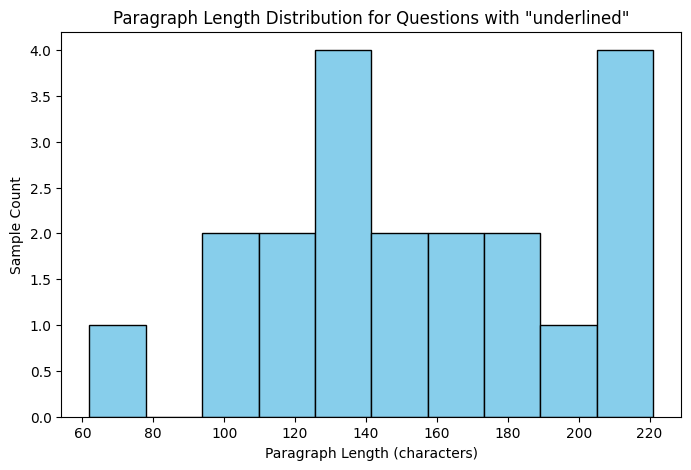

In [14]:
df_underlined = df[df['question'].str.contains('밑줄 친')]

num_samples = len(df_underlined)
print(f'Number of samples with "밑줄 친": {num_samples}')

plt.figure(figsize=(8,5))
plt.hist(df_underlined['paragraph_length'], bins=10, color='skyblue', edgecolor='black')
plt.title('Paragraph Length Distribution for Questions with "underlined"')
plt.xlabel('Paragraph Length (characters)')
plt.ylabel('Sample Count')
plt.show()

In [15]:
df_filtered = df[~df['question'].str.contains('밑줄 친') & (df['paragraph_length'] < 100)]

display(df_filtered[['paragraph','paragraph_length']].reset_index())

,index,paragraph,paragraph_length
0,1,"(가)은/는 의병계열과 애국계몽 운동 계열의 비밀결사가 모여 결성된 조직으로, 총사령 박상진을 중심으로 독립군 양성을 목적으로 하였다.",75
1,6,(가)신라의 한강 유역 확보 (나)관산성 전투(다) 백제의 웅진 천도 (라)고구려의 평양 천도,52
2,8,(가) 황제가 영원히 가시던 길에 엎드려 크게 통곡하던 우리는 …(중략) … 우리민족의 새로운 기백과 책동이 발발하기를 간절히 기대하는 바이다.－동아일보 1926년 6월 12일－,99
3,10,"(가)은/는 의병계열과 애국계몽 운동 계열의 비밀결사가 모여 결성된 조직으로, 총사령 박상진을 중심으로 독립군 양성을 목적으로 하였다.",75
4,13,(가) 도쿄에서 2․8 독립선언 발표 국내에서 6․10만 세 운동 발발,39
...,...,...,...
212,452,미국정신의학회(American Psychiatric Association)에서 발행한 ‘정신질환 진단 및 통계 편람(DSM-IV)’은 다음의 모든 항목에 대한 정보를 제공합니다.,99
213,453,"Lupe는 몇 달 동안 Craig와 사귀고 있습니다. 그녀는 그에게 푹 빠져서 함께 있는 시간이 즐겁기만 하지만, 그의 친구나 가족은 좋아할 수가 없습니다.",87
214,455,Bonneau 박사는 한 회사가 직원들의 사기와 생산성 향상을 위해 사무실을 재설계하도록 도왔습니다.,56
215,458,학생을 장애자로 분류하는 것에 대한 일반적인 비판은 개인들은 하나의 분류와 관련된 특성에 따라 수행하려는 경향이 있다는 것입니다.,72
